In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [4]:
llm = ChatMistralAI()

In [5]:
class SubState(TypedDict):

    eng_text:str
    hindi_text:str
    

In [9]:
def translate_text(state:SubState):

    prompt = f"convert the following provided english text to hindi text \n English text : {state['eng_text']}"

    result = llm .invoke(prompt)

    return {'hindi_text':result.content}

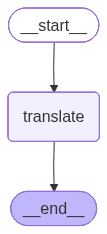

In [11]:
subgrah_build = StateGraph(SubState)

subgrah_build.add_node("translate",translate_text)

subgrah_build.add_edge(START,"translate")
subgrah_build.add_edge("translate",END)

subgraph = subgrah_build.compile()
subgraph


In [12]:
class parentState(TypedDict):

    query:str
    eng_ans:str
    hindi_ans:str

In [14]:
def generate(state :parentState):

    prompt = f" answer the follwoing query : {state['query']}"

    result = llm.invoke(prompt).content

    return{'eng_ans':result}

def translate(state:parentState):

    response = subgraph.invoke({'eng_text':state['eng_ans']})

    return {'hindi_ans':response['hindi_text']}

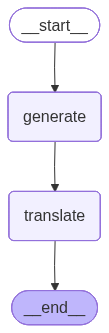

In [17]:
graph = StateGraph(parentState)

graph.add_node("generate",generate)
graph.add_node("translate",translate)

graph.add_edge(START,"generate")
graph.add_edge("generate","translate")
graph.add_edge("translate",END)

workflow = graph.compile()
workflow

In [19]:
workflow.invoke({'query': 'What is quantum physics'})

{'query': 'What is quantum physics',
 'eng_ans': 'Quantum physics, also known as **quantum mechanics**, is a fundamental branch of physics that studies the behavior of matter and energy at the smallest scales—typically at the level of atoms and subatomic particles (electrons, photons, quarks, etc.). Unlike classical physics, which describes the predictable, deterministic behavior of macroscopic objects, quantum physics introduces concepts that often defy classical intuition, such as:\n\n### **Key Principles of Quantum Physics:**\n1. **Wave-Particle Duality**:\n   - Particles (like electrons or photons) exhibit both wave-like and particle-like properties. This is famously demonstrated by the **double-slit experiment**, where particles create interference patterns like waves.\n\n2. **Quantization**:\n   - Certain properties (e.g., energy levels in atoms) are quantized, meaning they can only take discrete values rather than a continuous range.\n\n3. **Uncertainty Principle (Heisenberg)**: